# Billionaires — Complete Analysis Notebook
| **Course:** Social Data Visualization, DTU

This notebook contains all analyses in one place:

**Part A — Economics & Wealth Structure (5 analyses)**
1. What economic conditions produce billionaires? (GDP, tax, education)
2. Wealth concentration — Lorenz curve & Gini coefficient
3. Path to wealth — founder vs inherited vs executive
4. Company founding decade vs wealth
5. Age × self-made gap — does inheritance compound?

**Part B — Extended Angles (10 analyses)**
6. Expat billionaires — wealth migration & tax havens
7. Birth month pattern — the January effect
8. Source of wealth — granular breakdown
9. Company relationship — founder vs family vs investor
10. Wealth category — new sectors vs financial vs resource
11. Company type — new vs acquired vs privatized
12. Inflation vs wealth
13. Sector deep dive



In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# ── Plot style ──
plt.rcParams.update({
    'figure.facecolor' : '#0d0d0f',
    'axes.facecolor'   : '#16181d',
    'axes.edgecolor'   : '#2a2d38',
    'axes.labelcolor'  : '#e8eaf0',
    'xtick.color'      : '#7a7f94',
    'ytick.color'      : '#7a7f94',
    'text.color'       : '#e8eaf0',
    'grid.color'       : '#2a2d38',
    'grid.linewidth'   : 0.5,
    'axes.grid'        : True,
    'font.family'      : 'monospace',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
})

GOLD   = '#f0b429'
PURPLE = '#7c6af7'
GREEN  = '#3ecf8e'
RED    = '#e05c5c'
BLUE   = '#60a5fa'
PINK   = '#f472b6'
ORANGE = '#fb923c'

# ── Load data ──
df   = pd.read_csv('https://raw.githubusercontent.com/suhani-pandey/Final-Assignment_SocialDataVisualization/main/data/Billionaires%20Statistics%20Dataset.csv')
df_h = pd.read_csv('https://raw.githubusercontent.com/suhani-pandey/Final-Assignment_SocialDataVisualization/main/data/billionaires.csv')

print(f'DS1 shape: {df.shape}')
print(f'DS2 shape: {df_h.shape}')


DS1 shape: (2640, 35)
DS2 shape: (2614, 22)


In [21]:
# ── Clean DS1 ──
df['gdp_country_clean'] = (
    df['gdp_country'].str.replace('[$,]', '', regex=True).str.strip().astype(float)
)
df.drop(columns=['organization','title','state','residenceStateRegion'], inplace=True, errors='ignore')
mask = df['age'].isnull() & df['birthYear'].notnull()
df.loc[mask, 'age'] = 2023 - df.loc[mask, 'birthYear']
df.dropna(subset=['country', 'finalWorth'], inplace=True)
df['worth_b'] = df['finalWorth'] / 1000

# ── Clean DS2 ──
df_h.rename(columns={
    'wealth.type'             : 'wealth_type',
    'wealth.worth in billions': 'worth_b',
    'wealth.how.was founder'  : 'was_founder',
    'wealth.how.was political': 'was_political',
    'wealth.how.inherited'    : 'inherited_type',
    'company.founded'         : 'company_founded',
    'demographics.age'        : 'age',
    'demographics.gender'     : 'gender',
    'location.region'         : 'region',
    'wealth.how.industry'     : 'industry',
    'location.citizenship'    : 'country',
    'wealth.how.category'     : 'wealth_category',
    'company.sector'          : 'company_sector',
    'company.type'            : 'company_type',
    'company.relationship'    : 'company_relationship',
    'wealth.how.from emerging': 'from_emerging',
}, inplace=True)
df_h['inherited'] = df_h['inherited_type'].apply(
    lambda x: False if str(x).strip().lower() == 'not inherited' else True
)
df_h['region'] = df_h['region'].replace('0', np.nan)
df_h.dropna(subset=['gender'], inplace=True)
df_h['founded_decade'] = (df_h['company_founded'] // 10 * 10).astype('Int64')

# ── Derived columns ──
df['is_expat'] = df['countryOfCitizenship'] != df['country']
bins   = [0, 30, 40, 50, 60, 70, 80, 90, 120]
labels = ['<30','30s','40s','50s','60s','70s','80s','90+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

print(f'DS1 after cleaning: {df.shape}')
print(f'DS2 after cleaning: {df_h.shape}')
print('All ready!')


DS1 after cleaning: (2602, 35)
DS2 after cleaning: (2580, 24)
All ready!


---
## ═══════════════════════════════════════
## PART A — Economics & Wealth Structure
## ═══════════════════════════════════════


## 3. Analysis 1 — What Economic Conditions Produce Billionaires?

**Question:** Do countries with higher GDP per capita, better education, or lower taxes produce more billionaires per million people?

This uses the country-level variables in DS1 that are unique to this analysis.


In [22]:
# ── Build country-level stats table ──
country_agg = df.groupby('country').agg(
    bill_count       = ('personName', 'count'),
    population       = ('population_country', 'first'),
    gdp              = ('gdp_country_clean', 'first'),
    tax_rate         = ('total_tax_rate_country', 'first'),
    education        = ('gross_tertiary_education_enrollment', 'first'),
    life_expectancy  = ('life_expectancy_country', 'first'),
    avg_worth        = ('worth_b', 'mean'),
).reset_index()

# ── billionaires per million people ──
country_agg['bill_per_million'] = (
    country_agg['bill_count'] / (country_agg['population'] / 1e6)
).round(2)

# ── GDP per capita ──
country_agg['gdp_per_capita'] = (
    country_agg['gdp'] / country_agg['population']
).round(0)

# ── filter: only countries with population >= 1M (exclude micro-states like Monaco) ──
c_filtered = country_agg[country_agg['population'] >= 1_000_000].copy()

print(f'Countries with >= 1M population: {len(c_filtered)}')
print()
print('Top 12 by billionaires per million people:')
print(
    c_filtered.sort_values('bill_per_million', ascending=False)
    [['country','bill_count','bill_per_million','gdp_per_capita','tax_rate','education']]
    .head(12)
    .to_string(index=False)
)


Countries with >= 1M population: 64

Top 12 by billionaires per million people:
             country  bill_count  bill_per_million  gdp_per_capita  tax_rate  education
         Switzerland          78              9.10         81994.0      28.8       59.6
           Singapore          46              8.07         65233.0      21.0       84.8
              Cyprus           5              4.17         20495.0      22.4       75.9
              Israel          26              2.87         43641.0      25.3       63.4
              Sweden          26              2.53         51610.0      49.1       67.0
       United States         754              2.30         65281.0      36.6       88.2
United Arab Emirates          17              1.74         43103.0      15.9       36.8
              Norway           9              1.68         75420.0      36.2       82.0
           Australia          43              1.67         54050.0      47.4      113.1
             Finland           7        

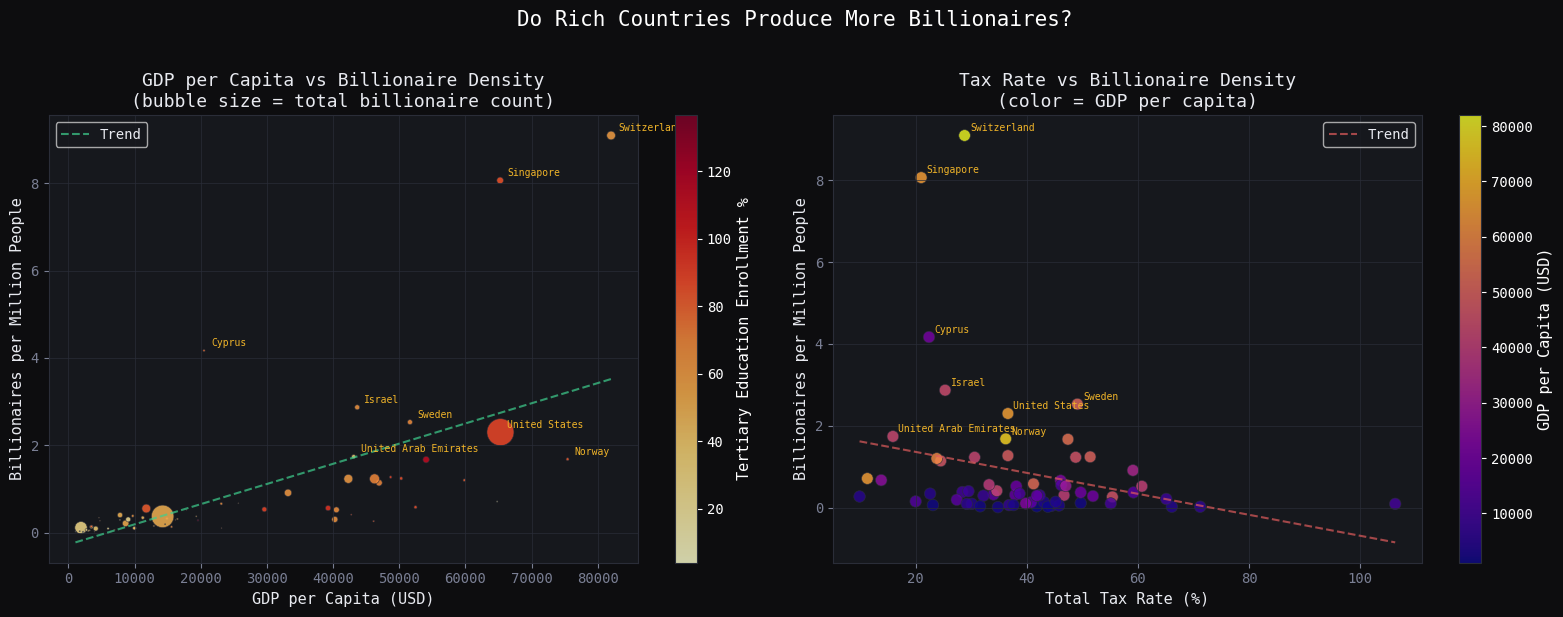


Correlation with Billionaires per Million:
  gdp_per_capita                      r = 0.632
  tax_rate                            r = -0.253
  education                           r = 0.247
  life_expectancy                     r = 0.398


In [23]:
# ── PLOT: GDP per capita vs Billionaires per million ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Do Rich Countries Produce More Billionaires?', fontsize=15, color='white', y=1.02)

plot_data = c_filtered.dropna(subset=['gdp_per_capita','bill_per_million','education','tax_rate'])

# ── Left: GDP per capita vs bill per million ──
sc = axes[0].scatter(
    plot_data['gdp_per_capita'],
    plot_data['bill_per_million'],
    c=plot_data['education'],
    cmap='YlOrRd',
    s=plot_data['bill_count'] * 0.5,
    alpha=0.8,
    edgecolors='#2a2d38',
    linewidth=0.5,
)
cbar = plt.colorbar(sc, ax=axes[0])
cbar.set_label('Tertiary Education Enrollment %', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

# ── label top countries ──
for _, row in plot_data.nlargest(8,'bill_per_million').iterrows():
    axes[0].annotate(
        row['country'], (row['gdp_per_capita'], row['bill_per_million']),
        fontsize=7, color=GOLD,
        xytext=(5, 3), textcoords='offset points'
    )

# ── trend line ──
z = np.polyfit(plot_data['gdp_per_capita'], plot_data['bill_per_million'], 1)
p = np.poly1d(z)
x_line = np.linspace(plot_data['gdp_per_capita'].min(), plot_data['gdp_per_capita'].max(), 100)
axes[0].plot(x_line, p(x_line), color=GREEN, linestyle='--', linewidth=1.5, alpha=0.7, label='Trend')
axes[0].legend()
axes[0].set_xlabel('GDP per Capita (USD)')
axes[0].set_ylabel('Billionaires per Million People')
axes[0].set_title('GDP per Capita vs Billionaire Density\n(bubble size = total billionaire count)')

# ── Right: Tax rate vs bill per million ──
sc2 = axes[1].scatter(
    plot_data['tax_rate'],
    plot_data['bill_per_million'],
    c=plot_data['gdp_per_capita'],
    cmap='plasma',
    s=70, alpha=0.8,
    edgecolors='#2a2d38', linewidth=0.5
)
cbar2 = plt.colorbar(sc2, ax=axes[1])
cbar2.set_label('GDP per Capita (USD)', color='white')
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

for _, row in plot_data.nlargest(8,'bill_per_million').iterrows():
    axes[1].annotate(
        row['country'], (row['tax_rate'], row['bill_per_million']),
        fontsize=7, color=GOLD,
        xytext=(4, 3), textcoords='offset points'
    )

z2 = np.polyfit(plot_data['tax_rate'], plot_data['bill_per_million'], 1)
p2 = np.poly1d(z2)
x2 = np.linspace(plot_data['tax_rate'].min(), plot_data['tax_rate'].max(), 100)
axes[1].plot(x2, p2(x2), color=RED, linestyle='--', linewidth=1.5, alpha=0.7, label='Trend')
axes[1].legend()
axes[1].set_xlabel('Total Tax Rate (%)')
axes[1].set_ylabel('Billionaires per Million People')
axes[1].set_title('Tax Rate vs Billionaire Density\n(color = GDP per capita)')

plt.tight_layout()
plt.savefig('plot_country_economics.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()

# ── Correlation summary ──
print('\nCorrelation with Billionaires per Million:')
corr_cols = ['gdp_per_capita','tax_rate','education','life_expectancy']
for col in corr_cols:
    r = plot_data['bill_per_million'].corr(plot_data[col])
    print(f'  {col:<35} r = {r:.3f}')


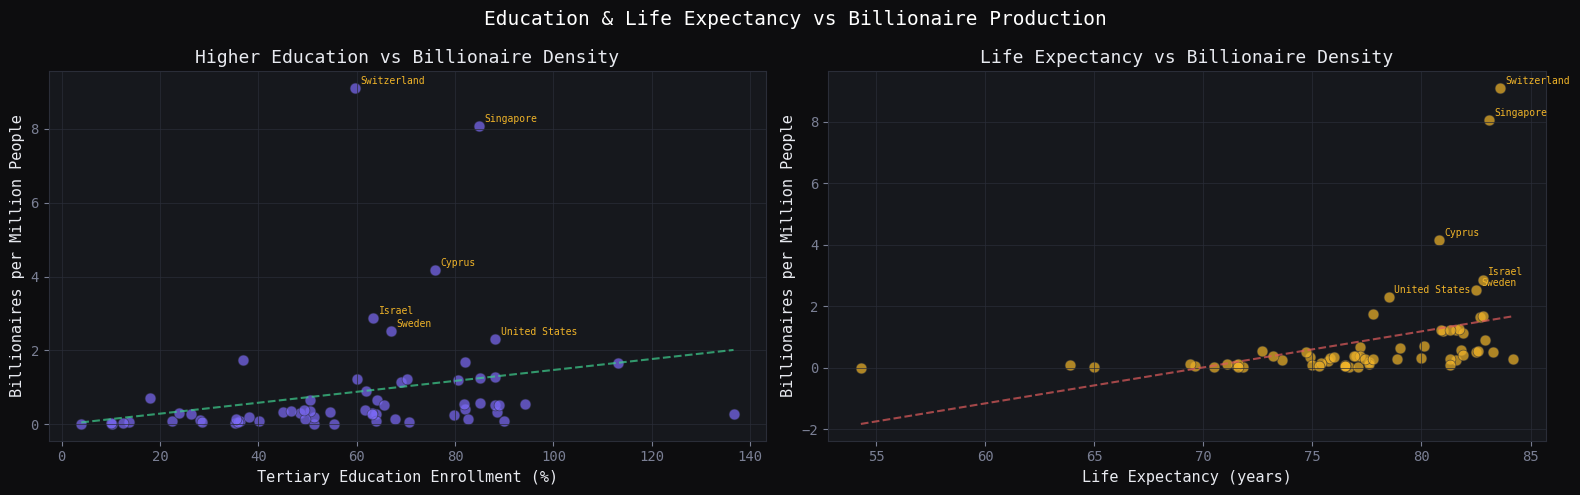

In [24]:
# ── PLOT: Education & Life Expectancy ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Education & Life Expectancy vs Billionaire Production', fontsize=14, color='white')

# Left: education vs bill per million
axes[0].scatter(
    plot_data['education'], plot_data['bill_per_million'],
    color=PURPLE, alpha=0.7, s=60, edgecolors='#2a2d38', linewidth=0.5
)
for _, row in plot_data.nlargest(6,'bill_per_million').iterrows():
    axes[0].annotate(row['country'], (row['education'], row['bill_per_million']),
                     fontsize=7, color=GOLD, xytext=(4,3), textcoords='offset points')
z3 = np.polyfit(plot_data['education'].dropna(), plot_data.loc[plot_data['education'].notna(),'bill_per_million'], 1)
p3 = np.poly1d(z3)
x3 = np.linspace(plot_data['education'].min(), plot_data['education'].max(), 100)
axes[0].plot(x3, p3(x3), color=GREEN, linestyle='--', linewidth=1.5, alpha=0.7)
axes[0].set_xlabel('Tertiary Education Enrollment (%)')
axes[0].set_ylabel('Billionaires per Million People')
axes[0].set_title('Higher Education vs Billionaire Density')

# Right: life expectancy vs bill per million
axes[1].scatter(
    plot_data['life_expectancy'], plot_data['bill_per_million'],
    color=GOLD, alpha=0.7, s=60, edgecolors='#2a2d38', linewidth=0.5
)
for _, row in plot_data.nlargest(6,'bill_per_million').iterrows():
    axes[1].annotate(row['country'], (row['life_expectancy'], row['bill_per_million']),
                     fontsize=7, color=GOLD, xytext=(4,3), textcoords='offset points')
z4 = np.polyfit(plot_data['life_expectancy'].dropna(), plot_data.loc[plot_data['life_expectancy'].notna(),'bill_per_million'], 1)
p4 = np.poly1d(z4)
x4 = np.linspace(plot_data['life_expectancy'].min(), plot_data['life_expectancy'].max(), 100)
axes[1].plot(x4, p4(x4), color=RED, linestyle='--', linewidth=1.5, alpha=0.7)
axes[1].set_xlabel('Life Expectancy (years)')
axes[1].set_ylabel('Billionaires per Million People')
axes[1].set_title('Life Expectancy vs Billionaire Density')

plt.tight_layout()
plt.savefig('plot_education_life.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 4. Analysis 2 — Wealth Concentration Within the Billionaire Class

**Question:** Even among billionaires, how unequal is the wealth? Do the top 10 own most of the total?

This uses a Lorenz curve — the standard tool for measuring inequality.


In [25]:
# ── Lorenz curve calculation ──
worth_sorted = np.sort(df['worth_b'].dropna().values)
n = len(worth_sorted)

# cumulative share of people (x axis)
cumulative_people = np.arange(1, n+1) / n

# cumulative share of wealth (y axis)
cumulative_wealth = np.cumsum(worth_sorted) / worth_sorted.sum()

# ── concentration stats ──
top1_pct   = int(n * 0.01)
top10_pct  = int(n * 0.10)
top50_pct  = int(n * 0.50)

top1_share  = worth_sorted[-top1_pct:].sum()  / worth_sorted.sum() * 100
top10_share = worth_sorted[-top10_pct:].sum() / worth_sorted.sum() * 100
top50_share = worth_sorted[-top50_pct:].sum() / worth_sorted.sum() * 100

print(f'Top  1% of billionaires own: {top1_share:.1f}% of total billionaire wealth')
print(f'Top 10% of billionaires own: {top10_share:.1f}% of total billionaire wealth')
print(f'Top 50% of billionaires own: {top50_share:.1f}% of total billionaire wealth')
print(f'Bottom 50% own:              {100-top50_share:.1f}%')
print()

# ── Gini coefficient ──
def gini(x):
    x = np.sort(x)
    n = len(x)
    index = np.arange(1, n+1)
    return (2 * (index * x).sum()) / (n * x.sum()) - (n+1)/n

g = gini(worth_sorted)
print(f'Gini coefficient (within billionaires): {g:.3f}')
print('(0 = perfect equality, 1 = one person owns everything)')


Top  1% of billionaires own: 17.8% of total billionaire wealth
Top 10% of billionaires own: 47.6% of total billionaire wealth
Top 50% of billionaires own: 83.4% of total billionaire wealth
Bottom 50% own:              16.6%

Gini coefficient (within billionaires): 0.550
(0 = perfect equality, 1 = one person owns everything)


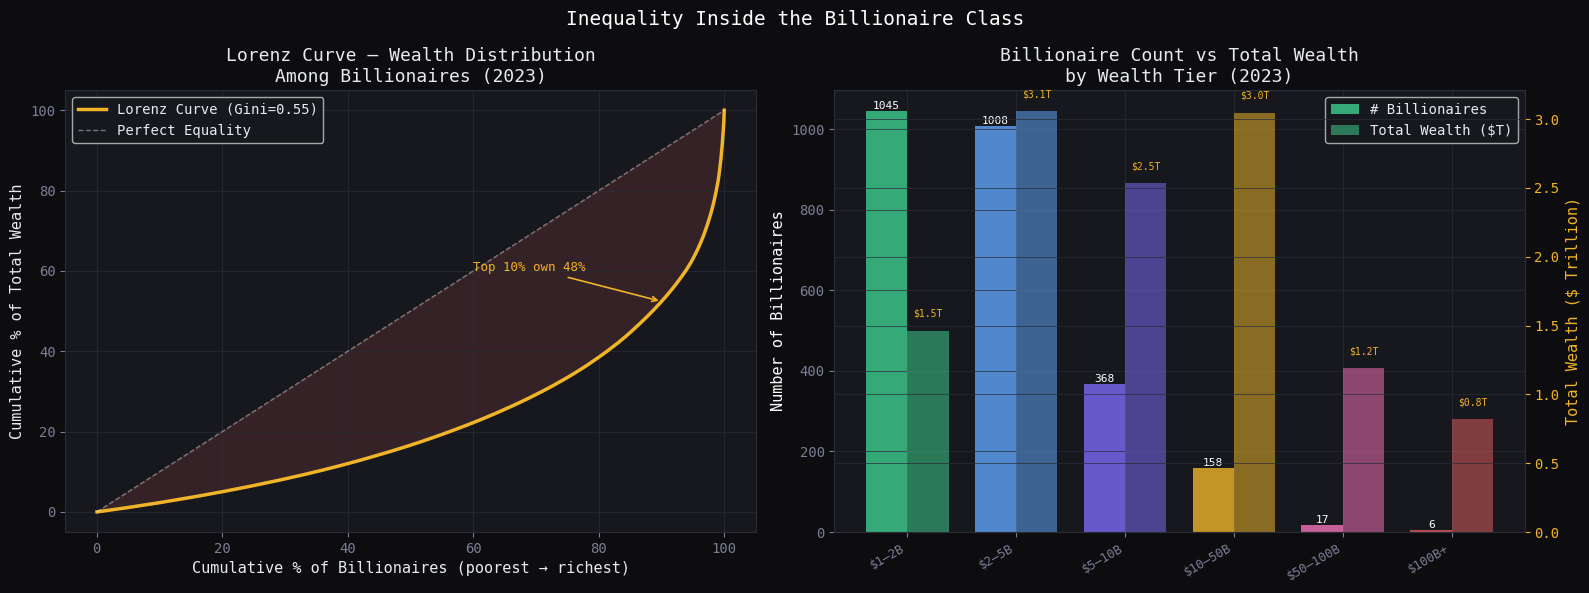

In [26]:
# ── PLOT: Lorenz curve + wealth tier breakdown ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Inequality Inside the Billionaire Class', fontsize=14, color='white')

# ── Left: Lorenz curve ──
axes[0].plot(cumulative_people * 100, cumulative_wealth * 100,
             color=GOLD, linewidth=2.5, label=f'Lorenz Curve (Gini={g:.2f})')
axes[0].plot([0, 100], [0, 100], color='white', linestyle='--', linewidth=1,
             alpha=0.4, label='Perfect Equality')

# shade the inequality gap
axes[0].fill_between(cumulative_people * 100, cumulative_people * 100,
                     cumulative_wealth * 100, alpha=0.15, color=RED)

# annotate key points
axes[0].annotate(f'Top 10% own {top10_share:.0f}%',
                 xy=(90, cumulative_wealth[int(n*0.9)] * 100),
                 xytext=(60, 60), color=GOLD, fontsize=9,
                 arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.2))

axes[0].set_xlabel('Cumulative % of Billionaires (poorest → richest)')
axes[0].set_ylabel('Cumulative % of Total Wealth')
axes[0].set_title('Lorenz Curve — Wealth Distribution\nAmong Billionaires (2023)')
axes[0].legend(loc='upper left')

# ── Right: worth tier stacked breakdown ──
worth_bins   = [0, 2, 5, 10, 50, 100, float('inf')]
worth_labels = ['$1–2B', '$2–5B', '$5–10B', '$10–50B', '$50–100B', '$100B+']
df['worth_tier'] = pd.cut(df['worth_b'], bins=worth_bins, labels=worth_labels, right=False)

tier_count  = df['worth_tier'].value_counts().sort_index()
tier_wealth = df.groupby('worth_tier', observed=True)['worth_b'].sum().sort_index()

x = np.arange(len(worth_labels))
width = 0.38
colors_tiers = [GREEN, BLUE, PURPLE, GOLD, '#f472b6', RED]

bars1 = axes[1].bar(x - width/2, tier_count.values, width,
                    label='# Billionaires', color=[c+'cc' for c in colors_tiers])
ax1b = axes[1].twinx()
bars2 = ax1b.bar(x + width/2, tier_wealth.values / 1000, width,
                 label='Total Wealth ($T)', color=[c+'88' for c in colors_tiers])

for bar, v in zip(bars1, tier_count.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+5, str(v),
                 ha='center', fontsize=8, color='white')
for bar, v in zip(bars2, tier_wealth.values/1000):
    ax1b.text(bar.get_x()+bar.get_width()/2, v+0.1, f'${v:.1f}T',
              ha='center', fontsize=7, color=GOLD)

axes[1].set_xticks(x)
axes[1].set_xticklabels(worth_labels, rotation=30, ha='right', fontsize=9)
axes[1].set_ylabel('Number of Billionaires', color='white')
ax1b.set_ylabel('Total Wealth ($ Trillion)', color=GOLD)
ax1b.tick_params(axis='y', colors=GOLD)
ax1b.yaxis.label.set_color(GOLD)
axes[1].set_title('Billionaire Count vs Total Wealth\nby Wealth Tier (2023)')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
axes[1].legend(lines1+lines2, labels1+labels2, loc='upper right')

plt.tight_layout()
plt.savefig('plot_lorenz.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 5. Analysis 3 — Path to Wealth: How You Got Rich Matters

**Question:** Does your path to wealth (founder, inherited, executive, privatized) determine how rich you get — and how has this changed from 1996 to 2014?

This uses the historical dataset's `wealth_type` and `inherited_type` columns.


In [27]:
# ── Wealth type stats ──
wt_stats = df_h.groupby('wealth_type').agg(
    count      = ('worth_b', 'count'),
    avg_worth  = ('worth_b', 'mean'),
    med_worth  = ('worth_b', 'median'),
).round(2).sort_values('avg_worth', ascending=False)

print('Wealth Type Summary:')
print(wt_stats.to_string())


Wealth Type Summary:
                          count  avg_worth  med_worth
wealth_type                                          
founder non-finance         713       3.79        2.0
privatized and resources    236       3.76        1.9
inherited                   931       3.75        2.3
self-made finance           500       3.09        1.9
executive                   190       2.64        1.7


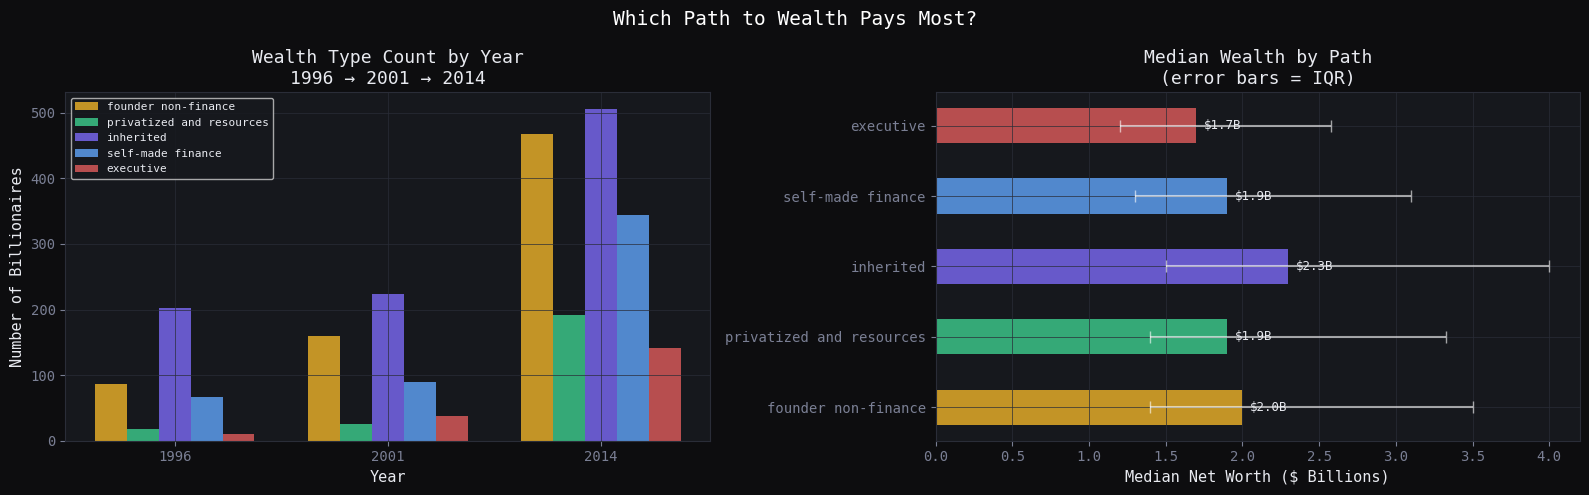

In [28]:
# ── PLOT 1: Wealth type — count vs avg worth ──
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Which Path to Wealth Pays Most?', fontsize=14, color='white')

wt_order = wt_stats.index.tolist()
pal = [GOLD, GREEN, PURPLE, BLUE, RED]

# Left: count by wealth type and year
wt_year = df_h.groupby(['year','wealth_type']).size().unstack(fill_value=0)
wt_year = wt_year[wt_order] if set(wt_order).issubset(wt_year.columns) else wt_year

x = np.arange(len(wt_year.index))
width = 0.15
for i, (wt, color) in enumerate(zip(wt_year.columns, pal)):
    axes[0].bar(x + i*width, wt_year[wt], width, label=wt, color=color+'cc', edgecolor='none')

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(wt_year.index)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Wealth Type Count by Year\n1996 → 2001 → 2014')
axes[0].legend(fontsize=8)

# Right: avg worth by wealth type (violin/box feel using bar + error)
wt_med = df_h.groupby('wealth_type')['worth_b'].median().reindex(wt_order)
wt_q1  = df_h.groupby('wealth_type')['worth_b'].quantile(0.25).reindex(wt_order)
wt_q3  = df_h.groupby('wealth_type')['worth_b'].quantile(0.75).reindex(wt_order)

bars = axes[1].barh(wt_order, wt_med, color=[c+'cc' for c in pal], edgecolor='none', height=0.5)
axes[1].errorbar(
    wt_med, range(len(wt_order)),
    xerr=[wt_med - wt_q1, wt_q3 - wt_med],
    fmt='none', color='white', capsize=4, linewidth=1.5, alpha=0.6
)
for bar, v in zip(bars, wt_med):
    axes[1].text(v + 0.05, bar.get_y()+bar.get_height()/2,
                 f'${v:.1f}B', va='center', fontsize=9)

axes[1].set_xlabel('Median Net Worth ($ Billions)')
axes[1].set_title('Median Wealth by Path\n(error bars = IQR)')

plt.tight_layout()
plt.savefig('plot_wealth_type.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


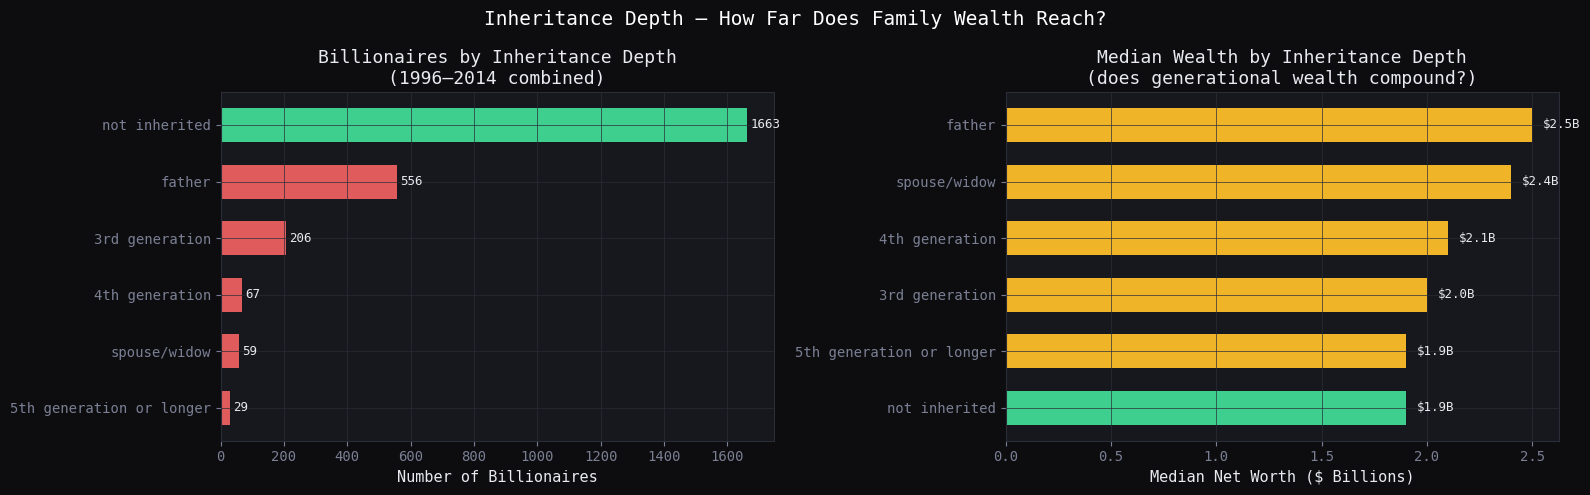


Inheritance depth — count and median worth:
                          count  median_worth_B
inherited_type                                 
not inherited              1663             1.9
father                      556             2.5
3rd generation              206             2.0
4th generation               67             2.1
spouse/widow                 59             2.4
5th generation or longer     29             1.9


In [29]:
# ── Inheritance depth breakdown ──
inh_counts = df_h['inherited_type'].value_counts()
inh_worth  = df_h.groupby('inherited_type')['worth_b'].median().reindex(inh_counts.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Inheritance Depth — How Far Does Family Wealth Reach?', fontsize=14, color='white')

# Left: count by inheritance type
colors_inh = [GREEN if 'not' in str(i).lower() else RED for i in inh_counts.index]
bars = axes[0].barh(inh_counts.index[::-1], inh_counts.values[::-1],
                    color=colors_inh[::-1], edgecolor='none', height=0.6)
for bar, v in zip(bars, inh_counts.values[::-1]):
    axes[0].text(v + 10, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Number of Billionaires')
axes[0].set_title('Billionaires by Inheritance Depth\n(1996–2014 combined)')

# Right: median worth by inheritance depth
inh_worth_sorted = inh_worth.sort_values(ascending=True)
colors_w = [GREEN if 'not' in str(i).lower() else GOLD for i in inh_worth_sorted.index]
bars2 = axes[1].barh(inh_worth_sorted.index, inh_worth_sorted.values,
                     color=colors_w, edgecolor='none', height=0.6)
for bar, v in zip(bars2, inh_worth_sorted.values):
    axes[1].text(v + 0.05, bar.get_y()+bar.get_height()/2, f'${v:.1f}B', va='center', fontsize=9)
axes[1].set_xlabel('Median Net Worth ($ Billions)')
axes[1].set_title('Median Wealth by Inheritance Depth\n(does generational wealth compound?)')

plt.tight_layout()
plt.savefig('plot_inheritance_depth.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()

print('\nInheritance depth — count and median worth:')
print(pd.DataFrame({'count': inh_counts, 'median_worth_B': inh_worth}).to_string())


## 6. Analysis 4 — When Was the Company Founded?

**Question:** Do billionaires from newer companies have more wealth? Or do century-old companies produce richer dynasties?


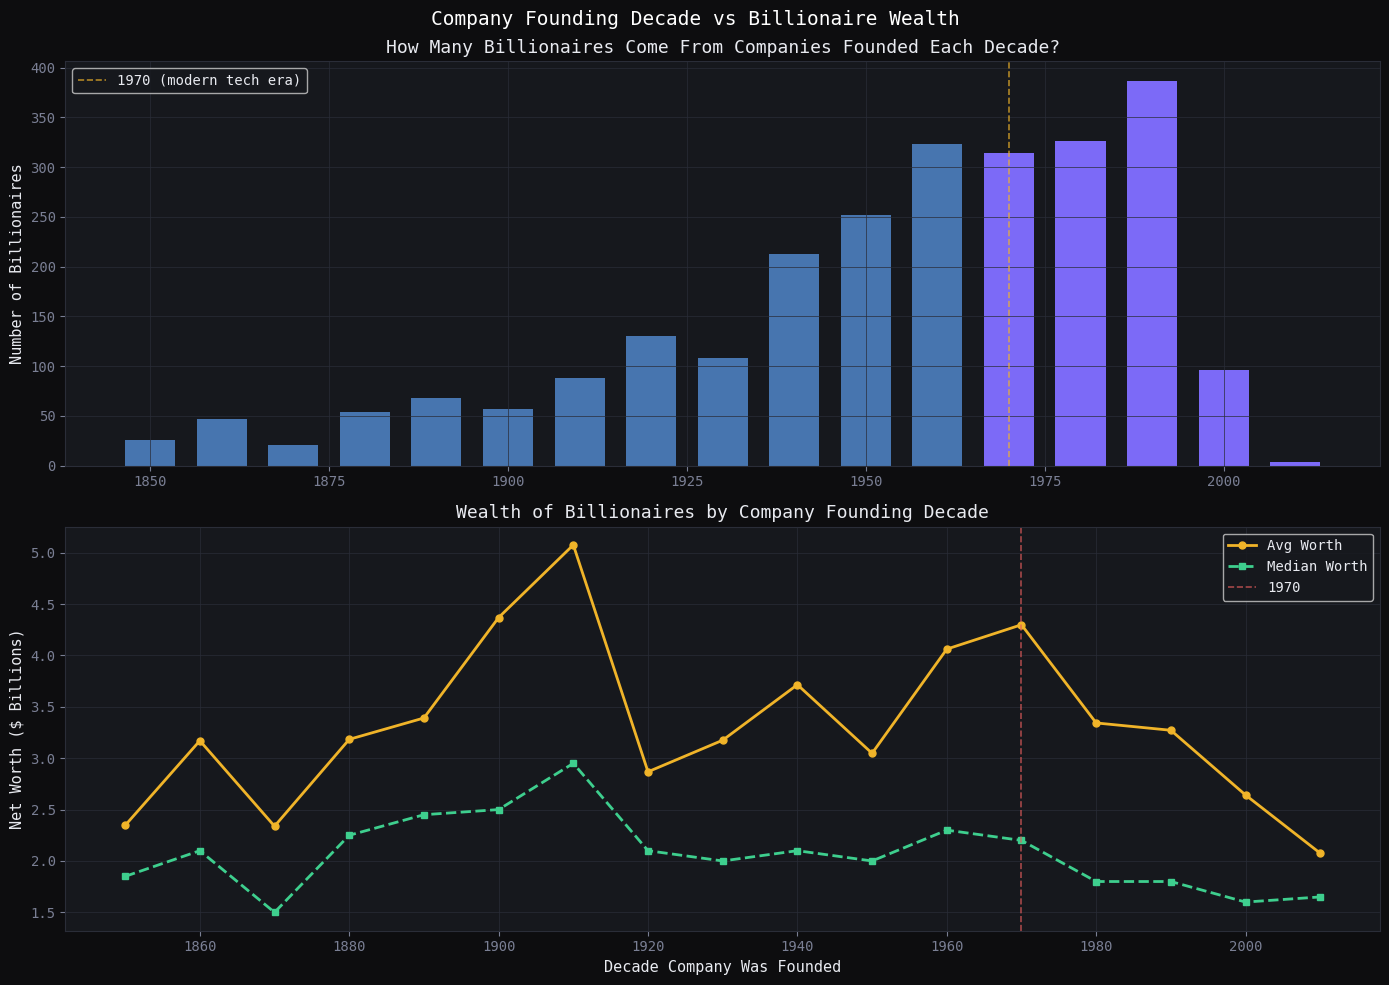


Founding decade summary (post-1920):
 founded_decade  count  avg_worth  med_worth
           1920    130   2.867692       2.10
           1930    108   3.175000       2.00
           1940    213   3.715023       2.10
           1950    252   3.047619       2.00
           1960    323   4.061300       2.30
           1970    314   4.298408       2.20
           1980    326   3.342945       1.80
           1990    387   3.271576       1.80
           2000     96   2.641667       1.60
           2010      4   2.075000       1.65


In [30]:
# ── Only meaningful decades (post-1850, enough data) ──
decade_stats = (
    df_h[df_h['company_founded'] >= 1850]
    .groupby('founded_decade')
    .agg(count=('worth_b','count'), avg_worth=('worth_b','mean'), med_worth=('worth_b','median'))
    .reset_index()
    .dropna()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Company Founding Decade vs Billionaire Wealth', fontsize=14, color='white')

decades = decade_stats['founded_decade'].astype(int)

# ── Top: billionaire count by founding decade ──
axes[0].bar(decades, decade_stats['count'],
            color=[PURPLE if d >= 1970 else BLUE+'aa' for d in decades],
            width=7, edgecolor='none')
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('How Many Billionaires Come From Companies Founded Each Decade?')
axes[0].axvline(1970, color=GOLD, linestyle='--', linewidth=1.2, alpha=0.7, label='1970 (modern tech era)')
axes[0].legend()

# ── Bottom: avg and median worth by founding decade ──
axes[1].plot(decades, decade_stats['avg_worth'],
             color=GOLD, marker='o', linewidth=2, markersize=5, label='Avg Worth')
axes[1].plot(decades, decade_stats['med_worth'],
             color=GREEN, marker='s', linewidth=2, markersize=5, linestyle='--', label='Median Worth')
axes[1].axvline(1970, color=RED, linestyle='--', linewidth=1.2, alpha=0.7, label='1970')
axes[1].set_xlabel('Decade Company Was Founded')
axes[1].set_ylabel('Net Worth ($ Billions)')
axes[1].set_title('Wealth of Billionaires by Company Founding Decade')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_founding_decade.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()

print('\nFounding decade summary (post-1920):')
print(decade_stats[decade_stats['founded_decade'] >= 1920].to_string(index=False))


## 7. Analysis 5 — Age, Self-Made Status & Wealth: Does Starting Rich Help?

**Question:** At each age group, do inherited billionaires have more wealth than self-made ones? Does the gap close or widen with age?


In [31]:
# ── Age groups ──
bins   = [0, 30, 40, 50, 60, 70, 80, 90, 120]
labels = ['<30','30s','40s','50s','60s','70s','80s','90+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

age_sm = df.groupby(['age_group','selfMade'], observed=True)['worth_b'].agg(['median','count']).reset_index()
age_sm.columns = ['age_group','selfMade','median_worth','count']
age_sm['label'] = age_sm['selfMade'].map({True:'Self-Made', False:'Inherited'})

print('Median worth by age group and self-made status:')
print(age_sm.pivot(index='age_group', columns='label', values='median_worth').to_string())


Median worth by age group and self-made status:
label      Inherited  Self-Made
age_group                      
<30             2.70        1.1
30s             1.90        2.5
40s             1.75        2.0
50s             2.70        2.1
60s             2.60        2.2
70s             2.70        2.5
80s             3.25        2.7
90+             5.10        2.9


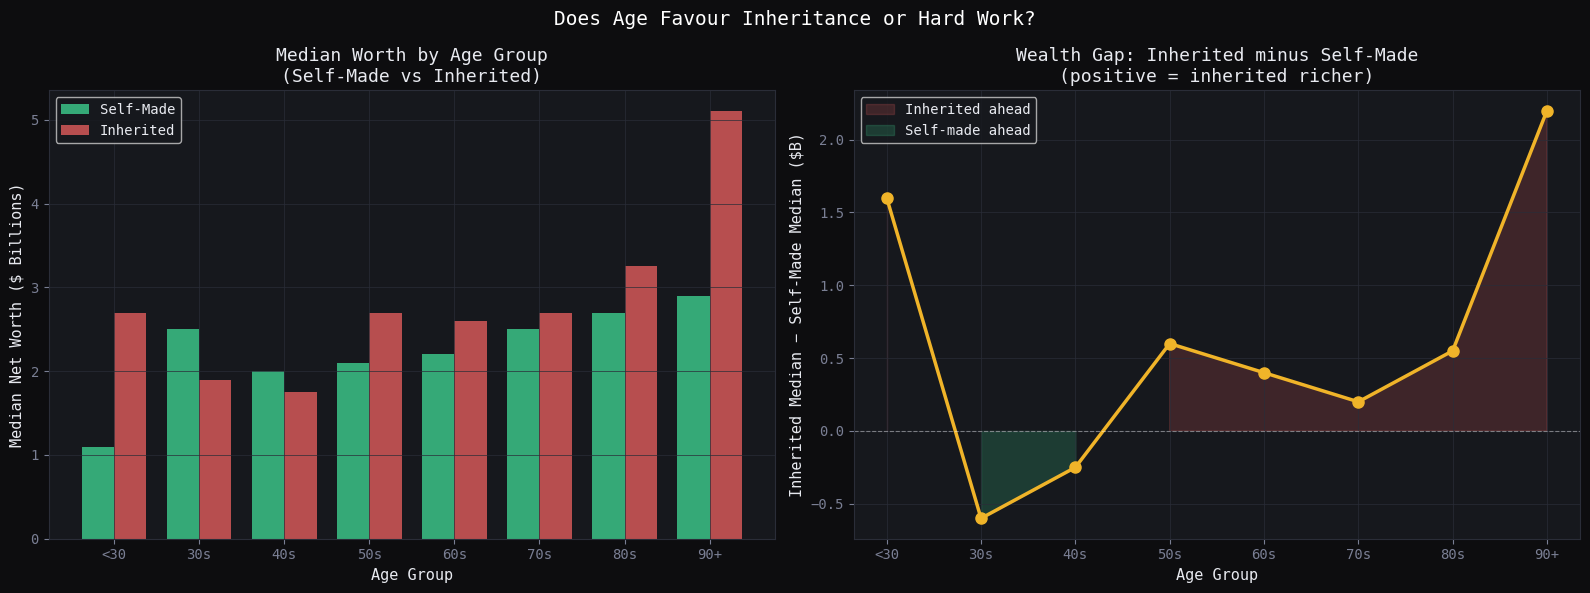

In [32]:
# ── PLOT ──
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Does Age Favour Inheritance or Hard Work?', fontsize=14, color='white')

sm_data  = age_sm[age_sm['selfMade'] == True]
inh_data = age_sm[age_sm['selfMade'] == False]
x = np.arange(len(labels))
width = 0.38

# ── Left: median worth by age group ──
bars1 = axes[0].bar(x - width/2, sm_data['median_worth'],  width, color=GREEN+'cc', label='Self-Made', edgecolor='none')
bars2 = axes[0].bar(x + width/2, inh_data['median_worth'], width, color=RED+'cc',   label='Inherited', edgecolor='none')

axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Median Net Worth ($ Billions)')
axes[0].set_title('Median Worth by Age Group\n(Self-Made vs Inherited)')
axes[0].legend()

# ── Right: gap line chart ──
gap = inh_data['median_worth'].values - sm_data['median_worth'].values
axes[1].plot(labels, gap, color=GOLD, marker='o', linewidth=2.5, markersize=8)
axes[1].axhline(0, color='white', linestyle='--', linewidth=0.8, alpha=0.4)
axes[1].fill_between(range(len(labels)), gap, 0,
                     where=(gap > 0), alpha=0.2, color=RED, label='Inherited ahead')
axes[1].fill_between(range(len(labels)), gap, 0,
                     where=(gap < 0), alpha=0.2, color=GREEN, label='Self-made ahead')
axes[1].set_xticks(range(len(labels)))
axes[1].set_xticklabels(labels)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Inherited Median − Self-Made Median ($B)')
axes[1].set_title('Wealth Gap: Inherited minus Self-Made\n(positive = inherited richer)')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_age_selfmade.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 8. Key Findings

1. **GDP per capita is positively correlated with billionaire density** — richer countries (Switzerland, Singapore, Israel) produce far more billionaires per million people than poor ones. But it's not a perfect predictor — USA has only 2.3 per million despite its GDP.

2. **Even within the billionaire class, wealth is extremely concentrated.** The top 10% of billionaires own ~47.6% of total billionaire wealth. The Gini coefficient within billionaires is high — they are not a homogeneous "rich" group.

3. **Your path to wealth determines your expected net worth.** Founder non-finance and inherited both average ~$3.7B, while executives average only $2.6B. Privatized wealth (post-Soviet, resource-based) shows the highest average — but extreme inequality within the group.

4. **Companies founded in the 1900–1920s and 1960–70s produced the wealthiest billionaires.** The 1960–70s tech-era founders peak is clear. Very recent companies (2000s) haven't yet had time to compound.

5. **Inherited billionaires dominate younger age groups; self-made overtake in older age groups.** At 90+, inherited median worth ($5.6B) dwarfs self-made ($2.75B) — multi-generational wealth compounds. But in the 30s and 40s, self-made actually leads.



---
## ═══════════════════════════════════════  
## PART B — Extended Angles
## ═══════════════════════════════════════


## 1. Expat Billionaires — Wealth Mobility Across Borders

**Question:** 12% of billionaires live outside their home country. Where do they go and where do they come from?
This reveals tax havens and wealth migration patterns.


In [33]:
# ── Identify expats ──
df['is_expat'] = df['countryOfCitizenship'] != df['country']
expats = df[df['is_expat']].copy()

print(f"Total billionaires     : {len(df)}")
print(f"Expat billionaires     : {len(expats)} ({len(expats)/len(df)*100:.1f}%)")
print(f"Avg worth expats       : ${expats['worth_b'].mean():.2f}B")
print(f"Avg worth non-expats   : ${df[~df['is_expat']]['worth_b'].mean():.2f}B")
print()
print("Top 10 destination countries (where expats move TO):")
print(expats['country'].value_counts().head(10).to_string())
print()
print("Top 10 origin countries (where expats come FROM):")
print(expats['countryOfCitizenship'].value_counts().head(10).to_string())


Total billionaires     : 2602
Expat billionaires     : 278 (10.7%)
Avg worth expats       : $4.59B
Avg worth non-expats   : $4.66B

Top 10 destination countries (where expats move TO):
country
United Kingdom          47
Switzerland             41
United States           41
China                   40
Hong Kong               19
Monaco                  15
United Arab Emirates    13
Singapore               13
Israel                   5
Austria                  4

Top 10 origin countries (where expats come FROM):
countryOfCitizenship
Russia            25
United States     21
Canada            21
Hong Kong         19
United Kingdom    15
Germany           14
Sweden            13
India             12
France            10
Italy              9


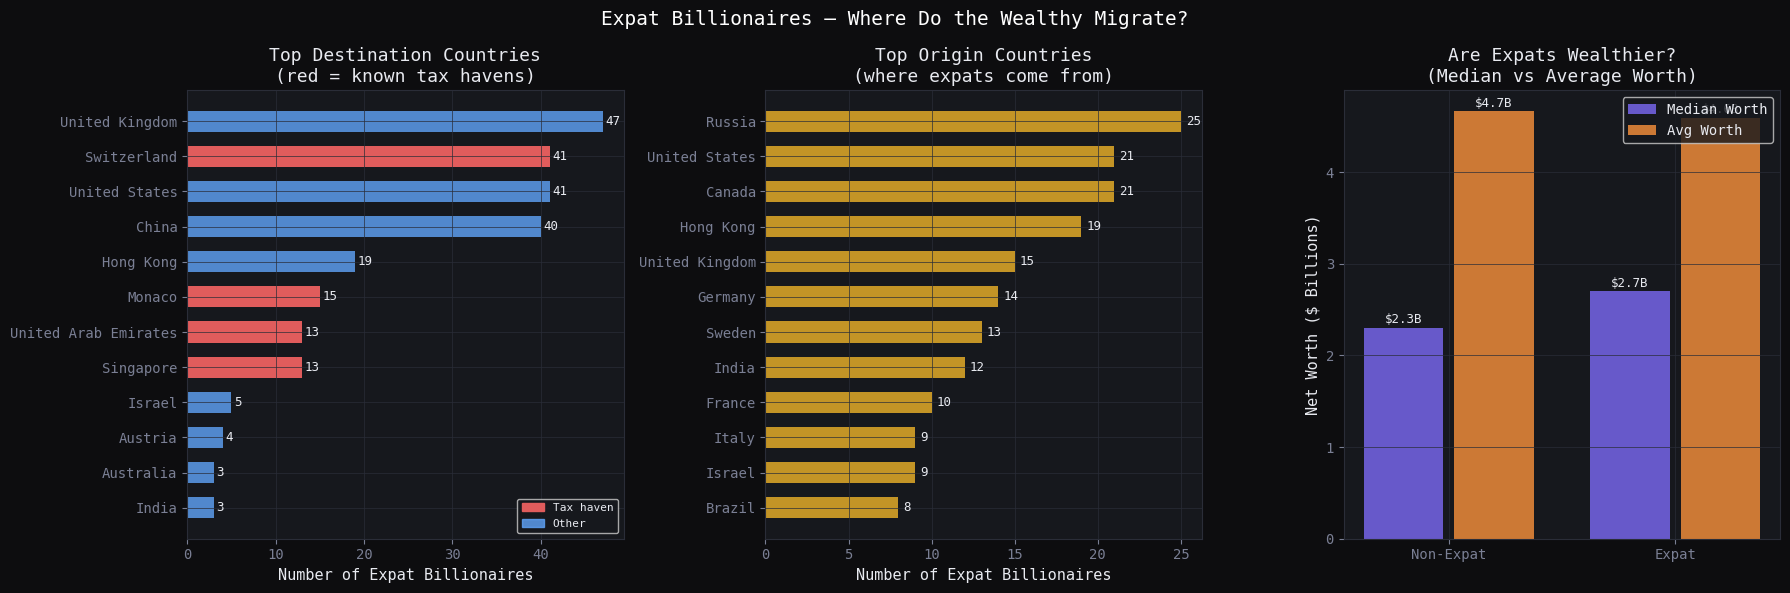

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Expat Billionaires — Where Do the Wealthy Migrate?', fontsize=14, color='white')

# ── Left: top destination countries ──
dest = expats['country'].value_counts().head(12)
colors_dest = [RED if c in ['Switzerland','Monaco','United Arab Emirates','Singapore'] else BLUE+'cc' for c in dest.index]
bars = axes[0].barh(dest.index[::-1], dest.values[::-1], color=colors_dest[::-1], edgecolor='none', height=0.6)
for bar, v in zip(bars, dest.values[::-1]):
    axes[0].text(v+0.3, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Number of Expat Billionaires')
axes[0].set_title('Top Destination Countries\n(red = known tax havens)')
red_patch = mpatches.Patch(color=RED, label='Tax haven')
blue_patch = mpatches.Patch(color=BLUE+'cc', label='Other')
axes[0].legend(handles=[red_patch, blue_patch], fontsize=8)

# ── Middle: top origin countries ──
origin = expats['countryOfCitizenship'].value_counts().head(12)
axes[1].barh(origin.index[::-1], origin.values[::-1], color=GOLD+'cc', edgecolor='none', height=0.6)
for bar, v in zip(axes[1].patches, origin.values[::-1]):
    axes[1].text(v+0.3, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
axes[1].set_xlabel('Number of Expat Billionaires')
axes[1].set_title('Top Origin Countries\n(where expats come from)')

# ── Right: expat vs non-expat worth comparison ──
groups = ['Non-Expat', 'Expat']
medians = [df[~df['is_expat']]['worth_b'].median(), expats['worth_b'].median()]
means   = [df[~df['is_expat']]['worth_b'].mean(),   expats['worth_b'].mean()]
x = np.arange(2)
axes[2].bar(x-0.2, medians, 0.35, color=PURPLE+'cc', label='Median Worth', edgecolor='none')
axes[2].bar(x+0.2, means,   0.35, color=ORANGE+'cc', label='Avg Worth',    edgecolor='none')
axes[2].set_xticks(x)
axes[2].set_xticklabels(groups)
axes[2].set_ylabel('Net Worth ($ Billions)')
axes[2].set_title('Are Expats Wealthier?\n(Median vs Average Worth)')
axes[2].legend()
for i,(m,a) in enumerate(zip(medians,means)):
    axes[2].text(i-0.2, m+0.05, f'${m:.1f}B', ha='center', fontsize=9)
    axes[2].text(i+0.2, a+0.05, f'${a:.1f}B', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('plot_expats.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


In [35]:
# ── Tax haven analysis ──
tax_havens = ['Switzerland','Monaco','United Arab Emirates','Singapore','Luxembourg','Cayman Islands']
expats['is_tax_haven'] = expats['country'].isin(tax_havens)

print("Expats who moved to tax havens:")
print(f"  Count : {expats['is_tax_haven'].sum()} ({expats['is_tax_haven'].mean()*100:.1f}% of expats)")
print(f"  Avg worth in tax havens     : ${expats[expats['is_tax_haven']]['worth_b'].mean():.2f}B")
print(f"  Avg worth NOT in tax havens : ${expats[~expats['is_tax_haven']]['worth_b'].mean():.2f}B")
print()

# Self-made breakdown among expats
print("Self-made % among expats vs non-expats:")
print(f"  Expats     : {expats['selfMade'].mean()*100:.1f}% self-made")
print(f"  Non-expats : {df[~df['is_expat']]['selfMade'].mean()*100:.1f}% self-made")


Expats who moved to tax havens:
  Count : 86 (30.9% of expats)
  Avg worth in tax havens     : $4.77B
  Avg worth NOT in tax havens : $4.51B

Self-made % among expats vs non-expats:
  Expats     : 69.8% self-made
  Non-expats : 69.2% self-made


## 2. Birth Month Pattern — The January Effect

**Question:** Are billionaires born disproportionately in certain months?
January has ~550 billionaires vs ~160 in February — a 3x difference. This could relate to the **relative age effect** (Malcolm Gladwell's Outliers).


In [36]:
month_counts = df['birthMonth'].value_counts().sort_index().dropna()
month_names  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

# Expected if uniform distribution
expected = len(df.dropna(subset=['birthMonth'])) / 12

print("Birth month distribution:")
for m, n, c in zip(range(1,13), month_names, month_counts.values):
    bar = '█' * int(c/10)
    print(f"  {n}: {c:4d}  {bar}")
print(f"Expected if uniform: {expected:.0f} per month")
print(f"January has {month_counts[1]/expected:.1f}x the expected count!")


Birth month distribution:
  Jan:  545  ██████████████████████████████████████████████████████
  Feb:  164  ████████████████
  Mar:  197  ███████████████████
  Apr:  175  █████████████████
  May:  176  █████████████████
  Jun:  160  ████████████████
  Jul:  191  ███████████████████
  Aug:  198  ███████████████████
  Sep:  197  ███████████████████
  Oct:  206  ████████████████████
  Nov:  150  ███████████████
  Dec:  179  █████████████████
Expected if uniform: 212 per month
January has 2.6x the expected count!


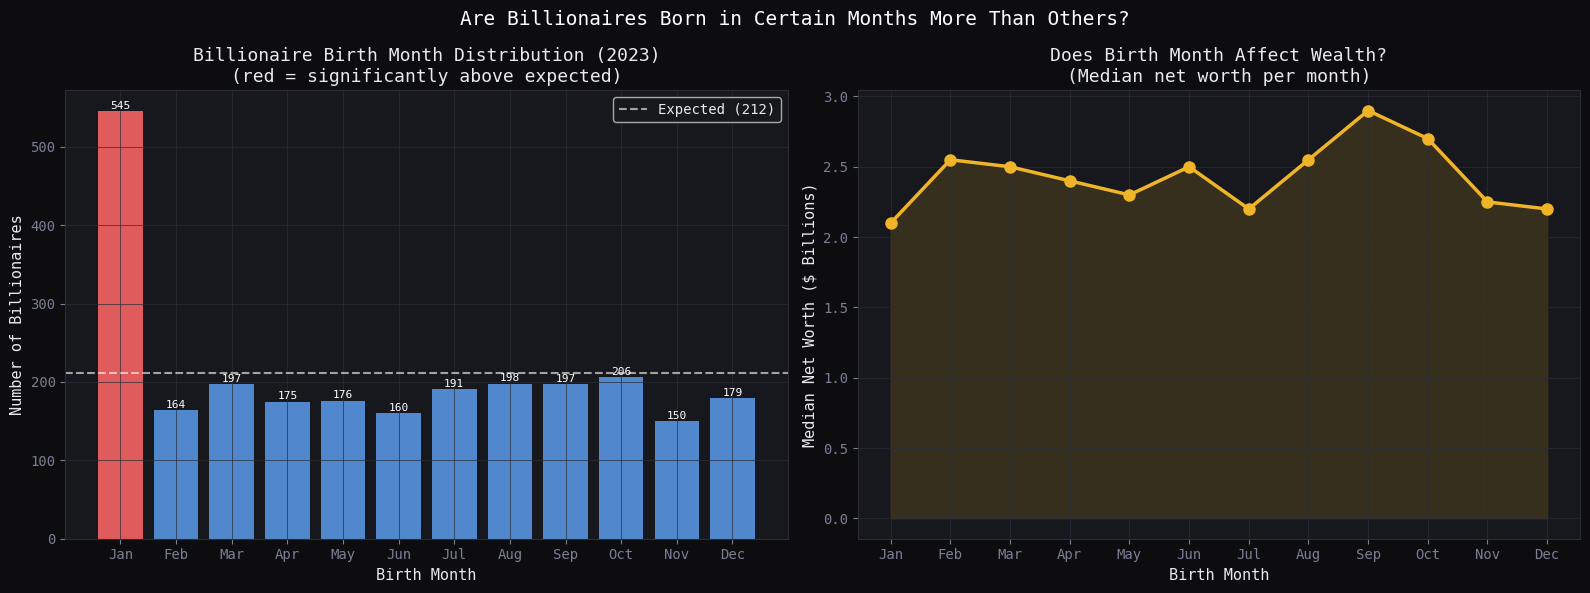

Chi-square test for uniform distribution:
  chi2 = 589.20, p-value = 0.000000
  Significant! Birth month distribution is NOT random.


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Are Billionaires Born in Certain Months More Than Others?', fontsize=14, color='white')

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
counts = [month_counts.get(i, 0) for i in range(1, 13)]
expected = sum(counts) / 12

# ── Left: bar chart with expected line ──
bar_colors = [RED if c > expected*1.3 else (GOLD if c > expected else BLUE+'cc') for c in counts]
bars = axes[0].bar(month_names, counts, color=bar_colors, edgecolor='none')
axes[0].axhline(expected, color='white', linestyle='--', linewidth=1.5,
                alpha=0.6, label=f'Expected ({expected:.0f})')
axes[0].set_xlabel('Birth Month')
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Billionaire Birth Month Distribution (2023)\n(red = significantly above expected)')
axes[0].legend()
for bar, v in zip(bars, counts):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+3, str(v),
                 ha='center', fontsize=8, color='white')

# ── Right: avg worth by birth month ──
df_bm = df.dropna(subset=['birthMonth']).copy()
df_bm['birthMonth'] = df_bm['birthMonth'].astype(int)
worth_by_month = df_bm.groupby('birthMonth')['worth_b'].median()
axes[1].plot(month_names, [worth_by_month.get(i,0) for i in range(1,13)],
             color=GOLD, marker='o', linewidth=2.5, markersize=8)
axes[1].fill_between(range(12),
                     [worth_by_month.get(i,0) for i in range(1,13)],
                     alpha=0.15, color=GOLD)
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(month_names)
axes[1].set_xlabel('Birth Month')
axes[1].set_ylabel('Median Net Worth ($ Billions)')
axes[1].set_title('Does Birth Month Affect Wealth?\n(Median net worth per month)')

plt.tight_layout()
plt.savefig('plot_birth_month.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()

# ── Chi-square test for uniformity ──
from scipy import stats
chi2, p = stats.chisquare(counts)
print(f"Chi-square test for uniform distribution:")
print(f"  chi2 = {chi2:.2f}, p-value = {p:.6f}")
print(f"  {'Significant! Birth month distribution is NOT random.' if p < 0.05 else 'Not significant.'}")


## 3. Source of Wealth — Granular Breakdown

The `source` column is more specific than `industry` — it tells us exactly what each billionaire made their money from (e.g. "Software", "Hedge funds", "Supermarkets").


In [38]:
# ── Top sources by count ──
source_counts = df['source'].value_counts().head(25)
source_worth  = df.groupby('source')['worth_b'].median()
source_sm     = df.groupby('source')['selfMade'].mean() * 100

print("Top 20 sources of wealth:")
summary = pd.DataFrame({
    'count'        : source_counts,
    'median_worth' : source_worth.reindex(source_counts.index).round(2),
    'selfmade_pct' : source_sm.reindex(source_counts.index).round(1)
})
print(summary.to_string())


Top 20 sources of wealth:
                    count  median_worth  selfmade_pct
source                                               
Real estate           149          2.30          67.1
Diversified            91          2.40          28.6
Investments            91          2.60          69.2
Pharmaceuticals        84          2.15          76.2
Software               63          1.80          95.2
Hedge funds            41          3.50         100.0
Private equity         40          3.50          97.5
Retail                 38          2.15          76.3
Chemicals              38          2.00          68.4
Manufacturing          34          1.40          79.4
Consumer goods         24          2.80          16.7
Banking                23          2.40          65.2
Finance                22          2.20          50.0
Mining                 21          2.00          52.4
Telecom                19          2.80          73.7
Auto parts             19          2.10          63.2
El

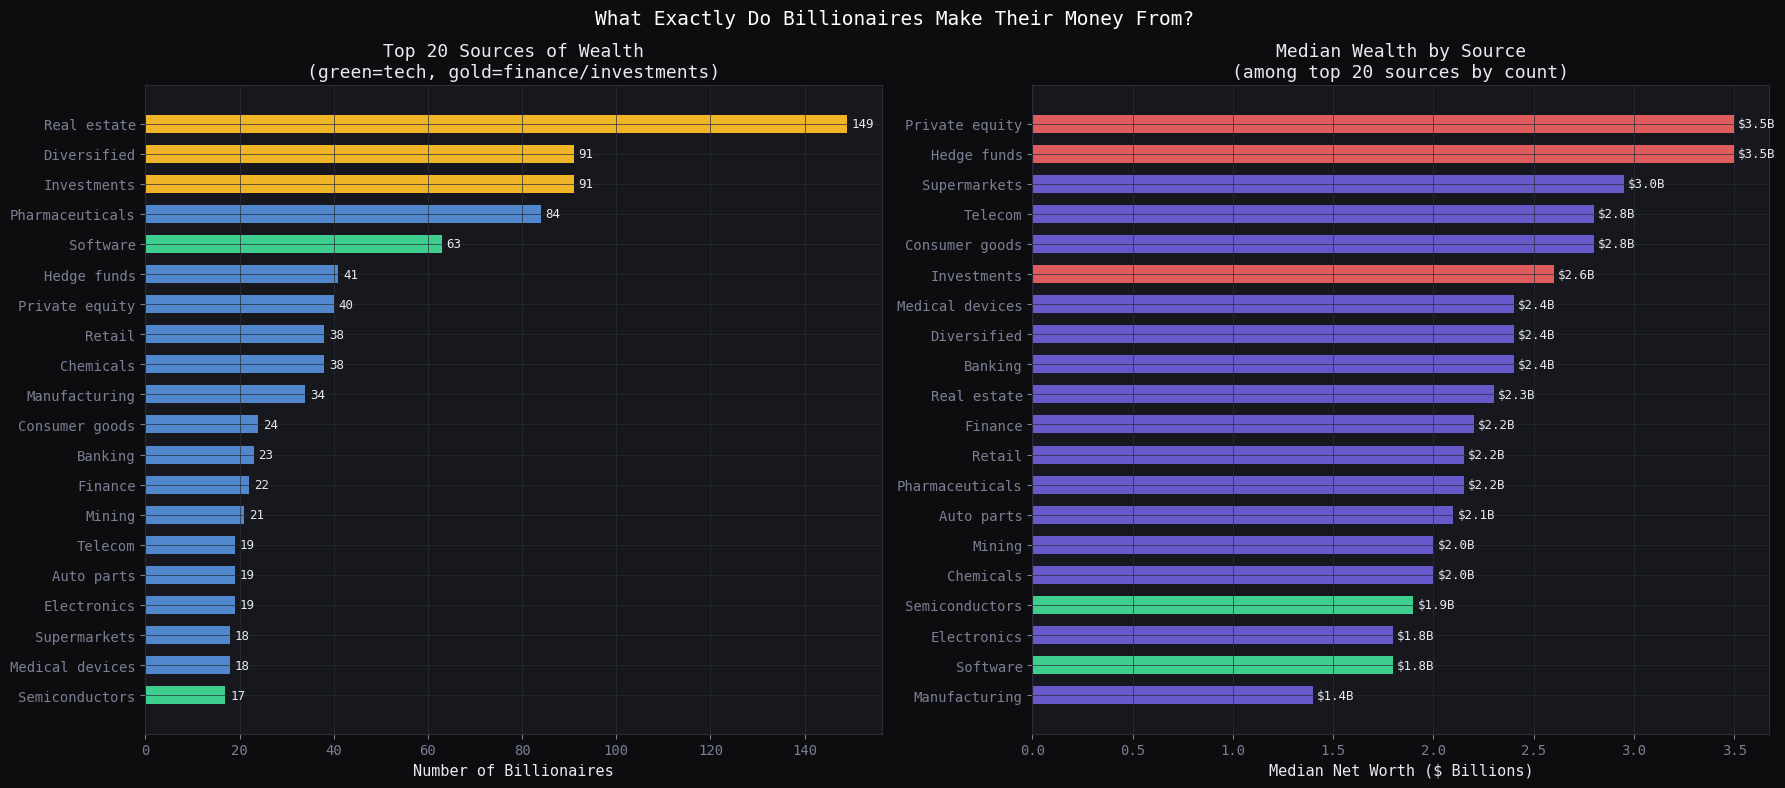

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('What Exactly Do Billionaires Make Their Money From?', fontsize=14, color='white')

top_sources = df['source'].value_counts().head(20)

# ── Left: count by source ──
colors_src = [GREEN if s in ['Software','Technology','Internet','Semiconductors','E-commerce']
              else (GOLD if s in ['Real estate','Investments','Diversified']
              else BLUE+'cc') for s in top_sources.index]
axes[0].barh(top_sources.index[::-1], top_sources.values[::-1],
             color=colors_src[::-1], edgecolor='none', height=0.6)
for bar, v in zip(axes[0].patches, top_sources.values[::-1]):
    axes[0].text(v+1, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Number of Billionaires')
axes[0].set_title('Top 20 Sources of Wealth\n(green=tech, gold=finance/investments)')

# ── Right: median worth by source (top 20 by count) ──
worth_src = df.groupby('source')['worth_b'].median().reindex(top_sources.index).sort_values(ascending=True)
bar_colors2 = [GREEN if s in ['Software','Semiconductors','Technology']
               else (RED if s in ['Hedge funds','Private equity','Investments']
               else PURPLE+'cc') for s in worth_src.index]
axes[1].barh(worth_src.index, worth_src.values, color=bar_colors2, edgecolor='none', height=0.6)
for bar, v in zip(axes[1].patches, worth_src.values):
    axes[1].text(v+0.02, bar.get_y()+bar.get_height()/2, f'${v:.1f}B', va='center', fontsize=9)
axes[1].set_xlabel('Median Net Worth ($ Billions)')
axes[1].set_title('Median Wealth by Source\n(among top 20 sources by count)')

plt.tight_layout()
plt.savefig('plot_source_wealth.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 4. Company Relationship — Founder vs Family vs Investor

The `company.relationship` column tells us HOW each person relates to their company wealth source. Cleaned into 5 main categories.


In [40]:
# ── Clean relationship into 5 categories ──
def clean_relationship(r):
    r = str(r).lower().strip()
    if 'founder' in r:   return 'Founder'
    if 'relation' in r:  return 'Family Relation'
    if 'investor' in r:  return 'Investor'
    if 'chairman' in r or 'chair' in r: return 'Chairman'
    if 'owner' in r:     return 'Owner'
    return 'Other'

df_h['relationship_clean'] = df_h['company_relationship'].apply(clean_relationship)

rel_stats = df_h.groupby('relationship_clean').agg(
    count     = ('worth_b','count'),
    avg_worth = ('worth_b','mean'),
    med_worth = ('worth_b','median'),
).round(2).sort_values('avg_worth', ascending=False)

print("Company Relationship Summary:")
print(rel_stats.to_string())


Company Relationship Summary:
                    count  avg_worth  med_worth
relationship_clean                             
Family Relation       955       3.77        2.3
Founder              1253       3.71        2.0
Investor               43       2.68        1.9
Other                  98       2.56        1.7
Chairman              136       2.36        1.8
Owner                  95       2.18        1.4


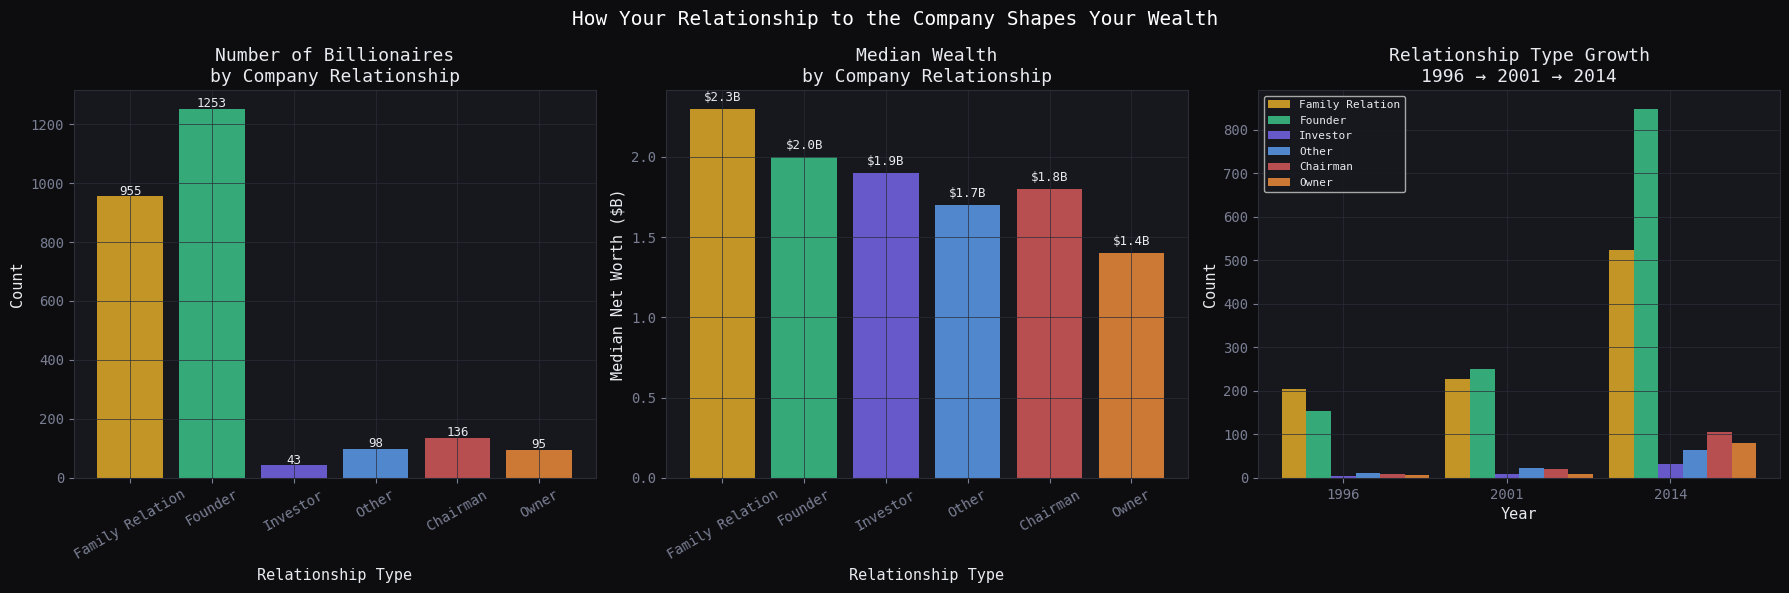

In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('How Your Relationship to the Company Shapes Your Wealth', fontsize=14, color='white')

pal = [GOLD, GREEN, PURPLE, BLUE, RED, ORANGE]
rel_order = rel_stats.index.tolist()

# ── Left: count ──
axes[0].bar(rel_order, rel_stats['count'], color=[c+'cc' for c in pal], edgecolor='none')
for bar, v in zip(axes[0].patches, rel_stats['count']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center', fontsize=9)
axes[0].set_xlabel('Relationship Type')
axes[0].set_ylabel('Count')
axes[0].set_title('Number of Billionaires\nby Company Relationship')
axes[0].tick_params(axis='x', rotation=30)

# ── Middle: median worth ──
axes[1].bar(rel_order, rel_stats['med_worth'], color=[c+'cc' for c in pal], edgecolor='none')
for bar, v in zip(axes[1].patches, rel_stats['med_worth']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'${v:.1f}B', ha='center', fontsize=9)
axes[1].set_xlabel('Relationship Type')
axes[1].set_ylabel('Median Net Worth ($B)')
axes[1].set_title('Median Wealth\nby Company Relationship')
axes[1].tick_params(axis='x', rotation=30)

# ── Right: relationship over time ──
rel_year = df_h.groupby(['year','relationship_clean']).size().unstack(fill_value=0)
years = rel_year.index.tolist()
x = np.arange(len(years))
width = 0.15
for i, (rel, color) in enumerate(zip(rel_order, pal)):
    if rel in rel_year.columns:
        axes[2].bar(x + i*width, rel_year[rel], width, label=rel,
                    color=color+'cc', edgecolor='none')
axes[2].set_xticks(x + width*2)
axes[2].set_xticklabels(years)
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Count')
axes[2].set_title('Relationship Type Growth\n1996 → 2001 → 2014')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_relationship.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 5. Wealth Category — New Sectors vs Financial vs Resource

`wealth.how.category` groups billionaires into: Financial, New Sectors, Non-Traded, Traded, Resource Related.
This is a higher-level view than industry.


In [42]:
# ── Clean category ──
main_cats = ['Financial','New Sectors','Non-Traded Sectors','Traded Sectors','Resource Related']
df_h['category_clean'] = df_h['wealth_category'].apply(
    lambda x: x if x in main_cats else np.nan
)

cat_stats = df_h.groupby('category_clean').agg(
    count     = ('worth_b','count'),
    avg_worth = ('worth_b','mean'),
    med_worth = ('worth_b','median'),
).round(2).sort_values('avg_worth', ascending=False)

print("Wealth Category Summary:")
print(cat_stats.to_string())


Wealth Category Summary:
                    count  avg_worth  med_worth
category_clean                                 
New Sectors           315       4.12        1.9
Non-Traded Sectors    591       3.79        2.0
Traded Sectors        550       3.61        2.1
Resource Related      245       3.44        2.0
Financial             793       3.24        2.1


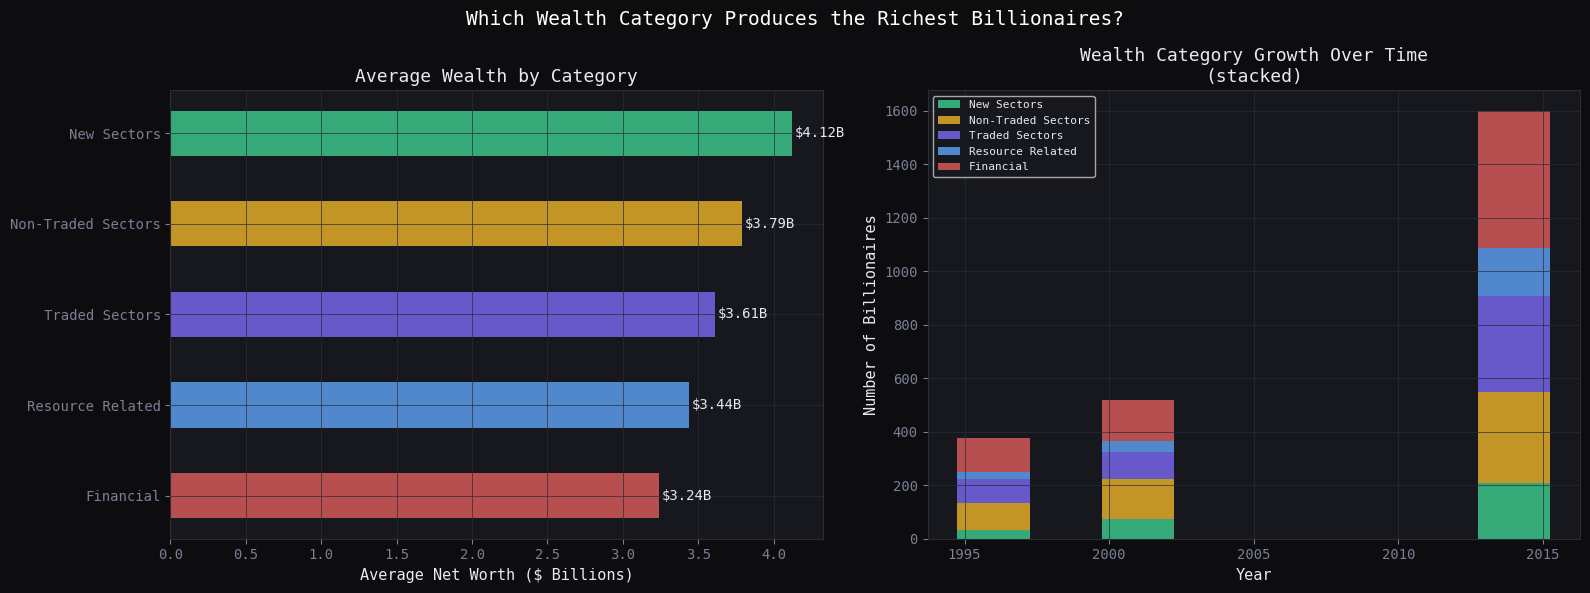

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Which Wealth Category Produces the Richest Billionaires?', fontsize=14, color='white')

cat_pal = [GREEN, GOLD, PURPLE, BLUE, RED]
cat_order = cat_stats.index.tolist()

# ── Left: avg worth per category ──
axes[0].barh(cat_order[::-1], cat_stats['avg_worth'][::-1],
             color=[c+'cc' for c in cat_pal[::-1]], edgecolor='none', height=0.5)
for bar, v in zip(axes[0].patches, cat_stats['avg_worth'][::-1]):
    axes[0].text(v+0.02, bar.get_y()+bar.get_height()/2, f'${v:.2f}B', va='center', fontsize=10)
axes[0].set_xlabel('Average Net Worth ($ Billions)')
axes[0].set_title('Average Wealth by Category')

# ── Right: category growth over time (stacked) ──
cat_year = df_h.groupby(['year','category_clean']).size().unstack(fill_value=0)
cat_year = cat_year[[c for c in cat_order if c in cat_year.columns]]
bottom = np.zeros(len(cat_year))
for cat, color in zip(cat_year.columns, cat_pal):
    axes[1].bar(cat_year.index, cat_year[cat], bottom=bottom,
                label=cat, color=color+'cc', edgecolor='none', width=2.5)
    bottom += cat_year[cat].values
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Billionaires')
axes[1].set_title('Wealth Category Growth Over Time\n(stacked)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_wealth_category.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 6. Company Type — New vs Acquired vs Privatized

Did the billionaire build a new company from scratch, acquire an existing one, or benefit from privatization?


In [44]:
# ── Clean company type ──
def clean_type(t):
    t = str(t).lower().strip()
    if 'new' in t:          return 'New Company'
    if 'acqui' in t:        return 'Acquired'
    if 'privat' in t:       return 'Privatized'
    if 'subsidiary' in t:   return 'Subsidiary'
    if 'merger' in t:       return 'Merger'
    return 'Other'

df_h['company_type_clean'] = df_h['company_type'].apply(clean_type)

type_stats = df_h.groupby('company_type_clean').agg(
    count     = ('worth_b','count'),
    avg_worth = ('worth_b','mean'),
    med_worth = ('worth_b','median'),
).round(2).sort_values('count', ascending=False)

print("Company Type Summary:")
print(type_stats.to_string())


Company Type Summary:
                    count  avg_worth  med_worth
company_type_clean                             
New Company          2289       3.49        2.0
Other                 229       3.41        2.0
Privatized             43       4.82        1.9
Subsidiary              9       1.78        1.4
Acquired                7      18.51       16.4
Merger                  3       4.50        3.5


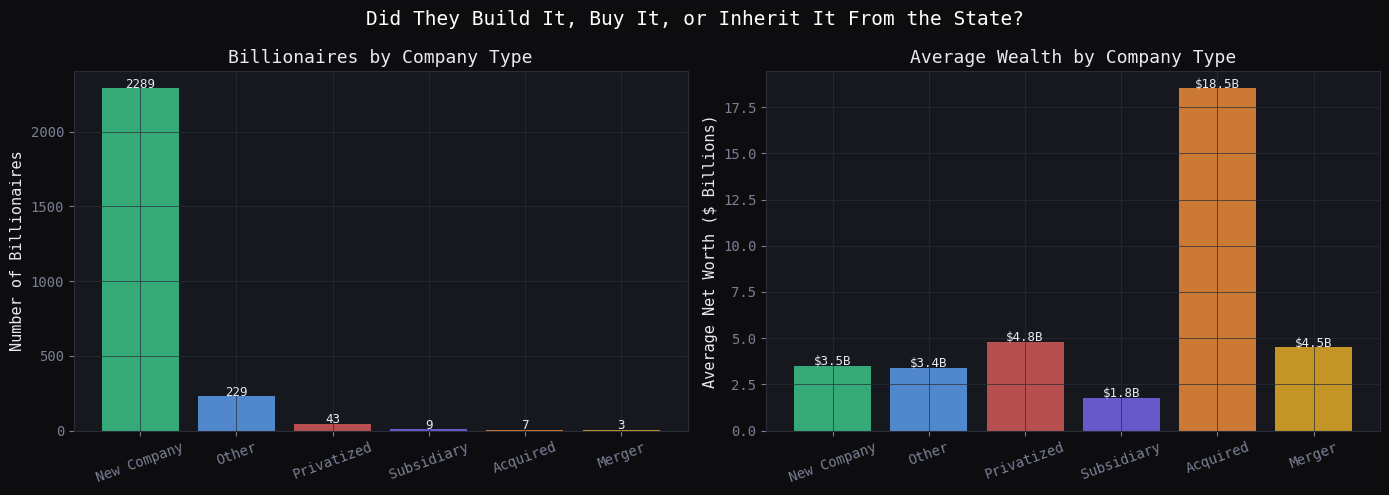

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Did They Build It, Buy It, or Inherit It From the State?', fontsize=14, color='white')

type_order = type_stats.index.tolist()
type_pal = [GREEN, BLUE, RED, PURPLE, ORANGE, GOLD]

# ── Left: count ──
axes[0].bar(type_order, type_stats['count'], color=[c+'cc' for c in type_pal], edgecolor='none')
for bar, v in zip(axes[0].patches, type_stats['count']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center', fontsize=9)
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Billionaires by Company Type')
axes[0].tick_params(axis='x', rotation=20)

# ── Right: avg wealth by type ──
axes[1].bar(type_order, type_stats['avg_worth'], color=[c+'cc' for c in type_pal], edgecolor='none')
for bar, v in zip(axes[1].patches, type_stats['avg_worth']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.05, f'${v:.1f}B', ha='center', fontsize=9)
axes[1].set_ylabel('Average Net Worth ($ Billions)')
axes[1].set_title('Average Wealth by Company Type')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('plot_company_type.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 7. Inflation (CPI Change) vs Billionaire Wealth

Do billionaires in high-inflation countries have more or less wealth? Does inflation erode or boost billionaire net worth?


In [46]:
# ── CPI change vs net worth ──
cpi_data = df.dropna(subset=['cpi_change_country','worth_b']).copy()

# Bin inflation into groups
cpi_data['inflation_group'] = pd.cut(
    cpi_data['cpi_change_country'],
    bins=[-5, 0, 2, 5, 10, 60],
    labels=['Deflation (<0%)','Low (0–2%)','Moderate (2–5%)','High (5–10%)','Very High (10%+)']
)

inf_stats = cpi_data.groupby('inflation_group', observed=True).agg(
    count     = ('worth_b','count'),
    avg_worth = ('worth_b','mean'),
    med_worth = ('worth_b','median'),
).round(2)

print("Inflation group stats:")
print(inf_stats.to_string())


Inflation group stats:
                  count  avg_worth  med_worth
inflation_group                              
Deflation (<0%)      19       5.39       3.00
Low (0–2%)          711       4.59       2.40
Moderate (2–5%)     764       3.69       2.00
High (5–10%)        930       5.66       2.70
Very High (10%+)     32       2.98       2.05


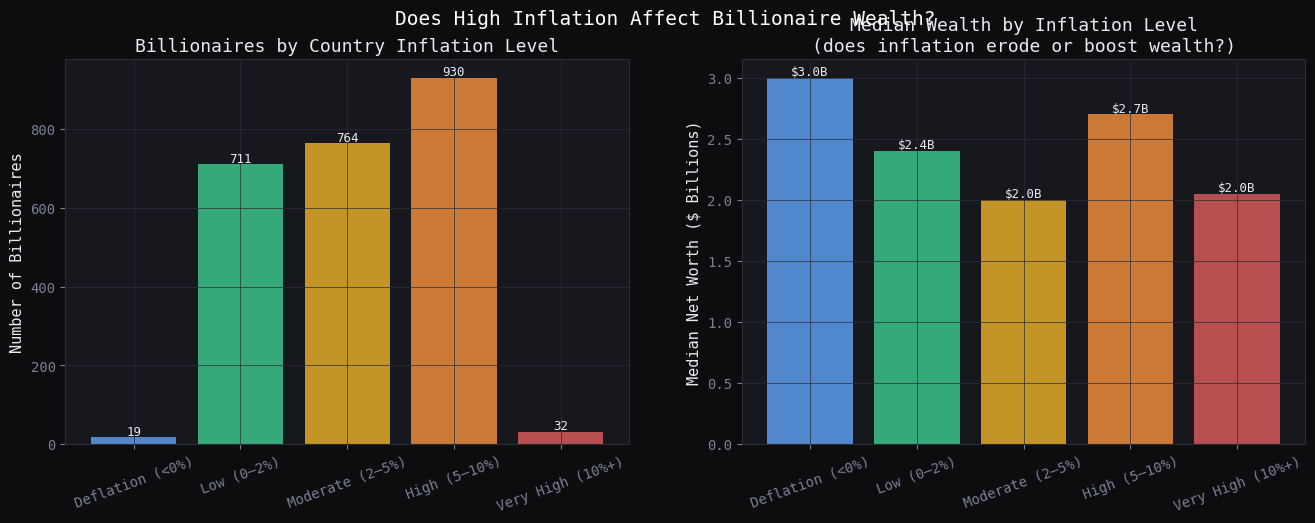

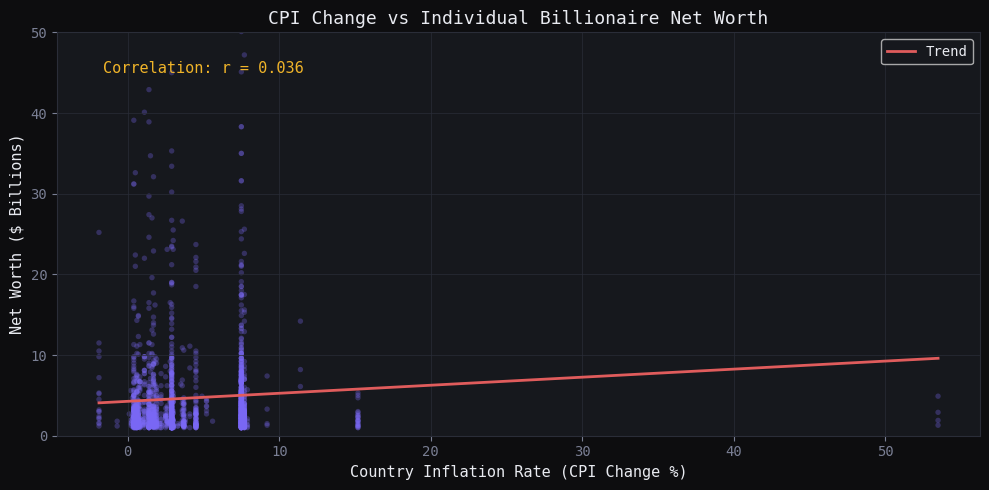

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Does High Inflation Affect Billionaire Wealth?', fontsize=14, color='white')

inf_labels = inf_stats.index.tolist()
inf_pal = [BLUE, GREEN, GOLD, ORANGE, RED]

# ── Left: count per inflation group ──
axes[0].bar(inf_labels, inf_stats['count'], color=[c+'cc' for c in inf_pal], edgecolor='none')
for bar, v in zip(axes[0].patches, inf_stats['count']):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+5, str(v), ha='center', fontsize=9)
axes[0].set_ylabel('Number of Billionaires')
axes[0].set_title('Billionaires by Country Inflation Level')
axes[0].tick_params(axis='x', rotation=20)

# ── Right: median worth per inflation group ──
axes[1].bar(inf_labels, inf_stats['med_worth'], color=[c+'cc' for c in inf_pal], edgecolor='none')
for bar, v in zip(axes[1].patches, inf_stats['med_worth']):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.02, f'${v:.1f}B', ha='center', fontsize=9)
axes[1].set_ylabel('Median Net Worth ($ Billions)')
axes[1].set_title('Median Wealth by Inflation Level\n(does inflation erode or boost wealth?)')
axes[1].tick_params(axis='x', rotation=20)

# Scatter
fig2, ax = plt.subplots(figsize=(10, 5))
ax.scatter(cpi_data['cpi_change_country'], cpi_data['worth_b'],
           alpha=0.3, color=PURPLE, s=15, edgecolors='none')
z = np.polyfit(cpi_data['cpi_change_country'], cpi_data['worth_b'], 1)
p = np.poly1d(z)
x_line = np.linspace(cpi_data['cpi_change_country'].min(), cpi_data['cpi_change_country'].max(), 100)
ax.plot(x_line, p(x_line), color=RED, linewidth=2, label='Trend')
ax.set_xlabel('Country Inflation Rate (CPI Change %)')
ax.set_ylabel('Net Worth ($ Billions)')
ax.set_title('CPI Change vs Individual Billionaire Net Worth')
ax.set_ylim(0, 50)
ax.legend()
corr = cpi_data['cpi_change_country'].corr(cpi_data['worth_b'])
ax.text(0.05, 0.9, f'Correlation: r = {corr:.3f}', transform=ax.transAxes,
        color=GOLD, fontsize=11)

plt.tight_layout()
plt.savefig('plot_inflation.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()


## 8. Company Sector Deep Dive (DS2)

`company.sector` is more granular than industry — 50+ unique sectors like "hedge funds", "oil", "pharmaceuticals", "software".


In [48]:
sector_stats = df_h.groupby('company_sector').agg(
    count     = ('worth_b','count'),
    avg_worth = ('worth_b','mean'),
    med_worth = ('worth_b','median'),
).round(2)

top_sectors_count = sector_stats.sort_values('count', ascending=False).head(15)
top_sectors_worth = sector_stats[sector_stats['count'] >= 20].sort_values('avg_worth', ascending=False).head(15)

print("Top 15 sectors by count:")
print(top_sectors_count.to_string())
print()
print("Top 15 sectors by avg worth (min 20 billionaires):")
print(top_sectors_worth.to_string())


Top 15 sectors by count:
                 count  avg_worth  med_worth
company_sector                              
real estate        176       3.50       2.10
retail             118       4.03       2.00
media              117       4.16       2.50
construction        96       2.22       1.70
banking             93       2.64       1.80
oil                 74       2.91       2.05
pharmaceuticals     73       2.61       1.80
software            67       2.61       1.80
hedge funds         50       3.56       1.95
technology          36       7.32       4.80
groceries           31       5.77       2.80
shipping            28       2.64       2.50
private equity      26       2.82       2.45
electronics         25       2.31       1.60
mining              25       4.47       2.30

Top 15 sectors by avg worth (min 20 billionaires):
                    count  avg_worth  med_worth
company_sector                                 
technology             36       7.32       4.80
groceries     

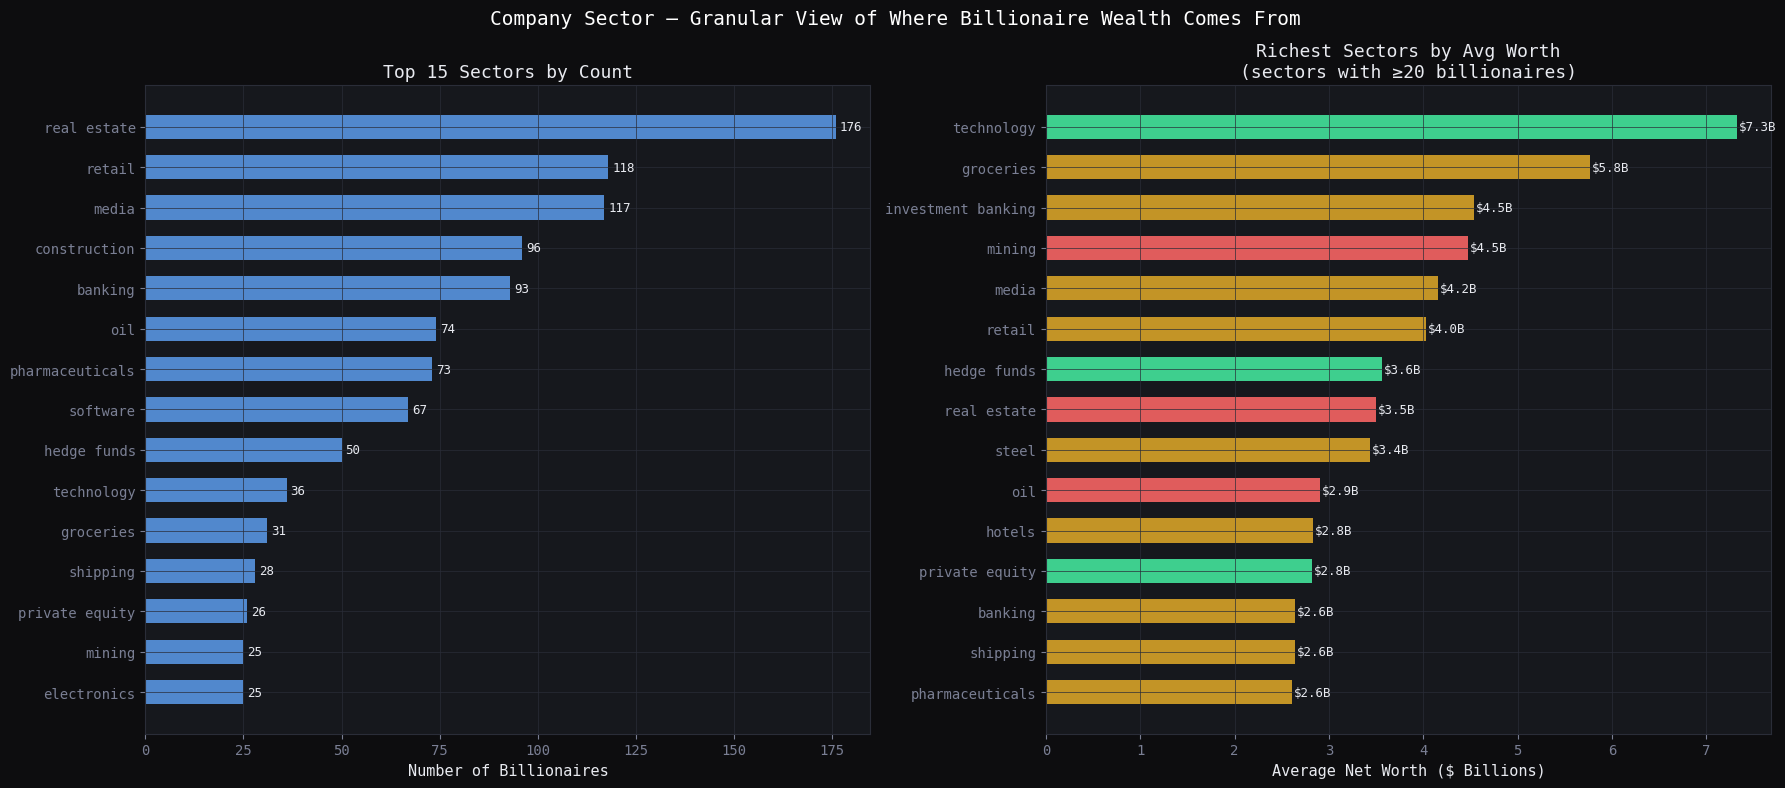

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Company Sector — Granular View of Where Billionaire Wealth Comes From', fontsize=14, color='white')

# ── Left: top 15 by count ──
tc = top_sectors_count.sort_values('count')
axes[0].barh(tc.index, tc['count'], color=BLUE+'cc', edgecolor='none', height=0.6)
for bar, v in zip(axes[0].patches, tc['count']):
    axes[0].text(v+1, bar.get_y()+bar.get_height()/2, str(v), va='center', fontsize=9)
axes[0].set_xlabel('Number of Billionaires')
axes[0].set_title('Top 15 Sectors by Count')

# ── Right: top 15 by avg worth ──
tw = top_sectors_worth.sort_values('avg_worth')
colors_w = [GREEN if s in ['software','technology','hedge funds','private equity']
            else (RED if s in ['oil','mining','real estate']
            else GOLD+'cc') for s in tw.index]
axes[1].barh(tw.index, tw['avg_worth'], color=colors_w, edgecolor='none', height=0.6)
for bar, v in zip(axes[1].patches, tw['avg_worth']):
    axes[1].text(v+0.02, bar.get_y()+bar.get_height()/2, f'${v:.1f}B', va='center', fontsize=9)
axes[1].set_xlabel('Average Net Worth ($ Billions)')
axes[1].set_title('Richest Sectors by Avg Worth\n(sectors with ≥20 billionaires)')

plt.tight_layout()
plt.savefig('plot_sector.png', dpi=150, bbox_inches='tight', facecolor='#0d0d0f')
plt.show()
